# World's largest islands

This dataset `largest-islands.csv` contains information about the 100 largest islands in the world. The unit for the `area` column is km2.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'largest-islands.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('largest-islands.csv')
df.head()

,region,island,area,countries,climate,rank
0,Africa,Madagascar,591896,Madagascar,tropics,4
1,Antarctic,Kerguelen,6200,"Antarctic Lands, France",temperate,91
2,Asia,Sumba,11153,Indonesia,tropics,65
3,Asia,Hainan,34300,China,tropics,37
4,Asia,Taiwan,36198,Taiwan,tropics,36


### Project Ideas

- What are the 10 largest islands in the tropics?

- What are the largest islands in each `region`?

- Create a line graph with `area` on the y-axis and `rank` on the x-axis. The data should be ordered by `rank`, from largest to smallest.

- What islands are composed of multiple countries?
	- Hint: try `countries.str.contains(",")`

In [3]:
# YOUR CODE HERE (add more cells as needed)

In [4]:
print(df.columns)

Index(['region', 'island', 'area', 'countries', 'climate', 'rank'], dtype='str')


In [5]:
tropical = df[
    df["region"] == "Yes"
]

In [6]:
largest = tropical.sort_values(
    "area",
    ascending=False
)

In [7]:
tropical = df[
    df["climate"] == "tropics"
]

In [8]:
top10 = tropical.sort_values(
    "area",
    ascending=False
).head(10)

print(top10)

           region      island    area                    countries  climate  \
86        Oceania  New Guinea  821400  Papua New Guinea, Indonesia  tropics   
23           Asia      Borneo  755000  Indonesia, Malaysia, Brunei  tropics   
0          Africa  Madagascar  591896                   Madagascar  tropics   
28           Asia     Sumatra  480793                    Indonesia  tropics   
22           Asia    Sulawesi  188522                    Indonesia  tropics   
21           Asia        Java  129438                    Indonesia  tropics   
80  North America        Cuba  109884                         Cuba  tropics   
26           Asia       Luzon  104688                  Philippines  tropics   
14           Asia    Mindanao   94630                  Philippines  tropics   
73  North America  Hispaniola   76192    Dominican Republic, Haiti  tropics   

    rank  
86     2  
23     3  
0      4  
28     6  
22    11  
21    13  
80    16  
26    17  
14    19  
73    23  


In [9]:
print(
    top10[
        ["island", "area", "countries"]
    ]
)

        island    area                    countries
86  New Guinea  821400  Papua New Guinea, Indonesia
23      Borneo  755000  Indonesia, Malaysia, Brunei
0   Madagascar  591896                   Madagascar
28     Sumatra  480793                    Indonesia
22    Sulawesi  188522                    Indonesia
21        Java  129438                    Indonesia
80        Cuba  109884                         Cuba
26       Luzon  104688                  Philippines
14    Mindanao   94630                  Philippines
73  Hispaniola   76192    Dominican Republic, Haiti


In [10]:
largest = df.loc[df.groupby("region")["area"].idxmax()]
print(largest[["island", "area", "region"]])

                             island     area         region
0                        Madagascar   591896         Africa
1                         Kerguelen     6200      Antarctic
23                           Borneo   755000           Asia
35                         Sakhalin    76400        Eurasia
41                        Greenland  2166086         Europe
75                    Baffin Island   507451  North America
86                       New Guinea   821400        Oceania
98  Isla Grande de Tierra del Fuego    47992  South America


In [11]:
ordered = df.sort_values("rank")

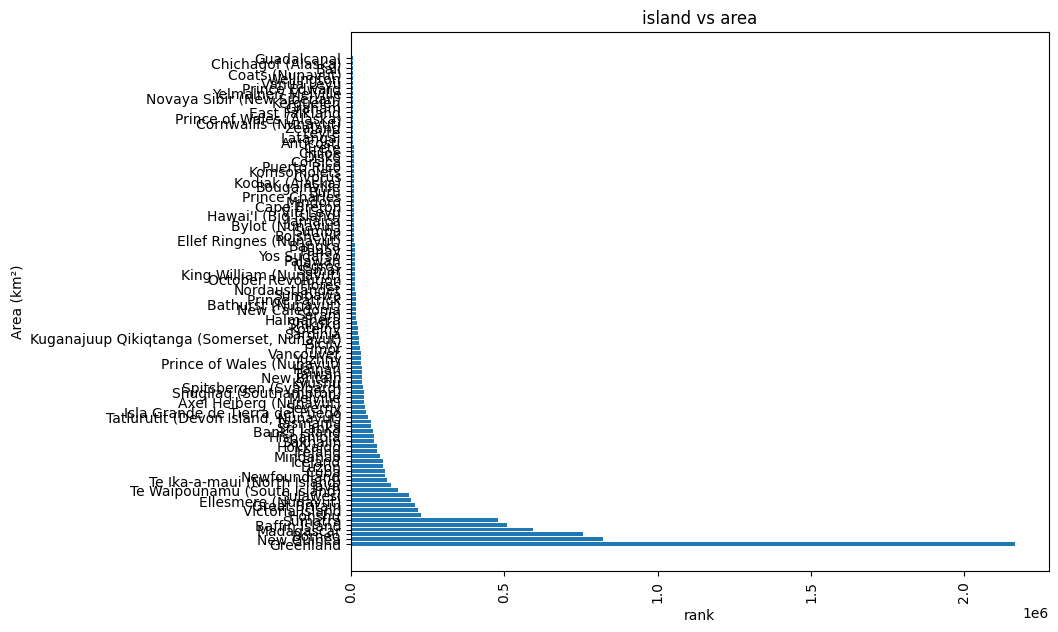

In [17]:
plt.figure(figsize=(9, 7))
plt.barh(ordered["island"], ordered["area"])
plt.xticks(rotation=90)
plt.xlabel("rank")
plt.ylabel("Area (km²)")
plt.title("island vs area")
plt.show()

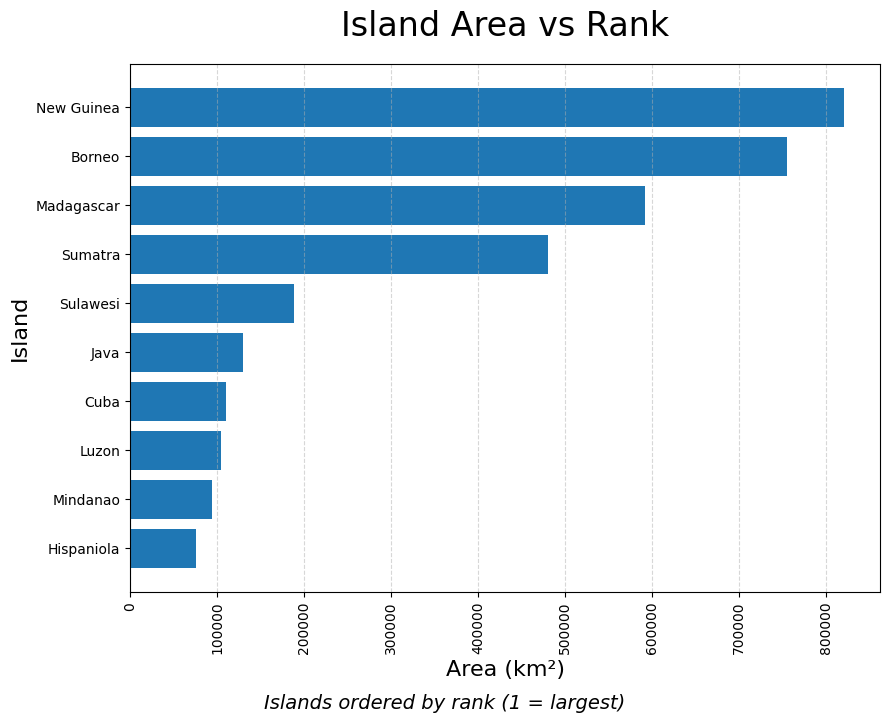

In [20]:
plt.figure(figsize=(9, 7))
plt.barh(top10["island"], top10["area"])
plt.xticks(rotation=90)
plt.xlabel("rank")
plt.ylabel("Area (km²)")
plt.title("island vs area")
# Invert y-axis so largest appears at top
plt.gca().invert_yaxis()

# Labels and title
plt.title(
    "Island Area vs Rank",
    fontsize=24,
    pad=20
)

plt.xlabel(
    "Area (km²)",
    fontsize=16
)

plt.ylabel(
    "Island",
    fontsize=16
)

# Grid for cleaner look
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

# Improve spacing
plt.tight_layout()

# Optional subtitle
plt.figtext(
    0.5,
    -0.02,
    "Islands ordered by rank (1 = largest)",
    ha="center",
    fontsize=14,
    style="italic"
)

# Show graph
plt.show()

In [21]:
multi_country = df[
    df["countries"].str.contains(
        ",",
        na=False
    )
]

In [22]:
print(
    multi_country[
        ["island", "countries"]
    ]
)

                             island                    countries
1                         Kerguelen      Antarctic Lands, France
23                           Borneo  Indonesia, Malaysia, Brunei
45                          Ireland      Ireland, United Kingdom
50                           Cyprus       Cyprus, United Kingdom
73                       Hispaniola    Dominican Republic, Haiti
86                       New Guinea  Papua New Guinea, Indonesia
98  Isla Grande de Tierra del Fuego             Chile, Argentina


In [23]:
df["country_count"] = (
    df["countries"]
    .str.split(",")
    .str.len()
)

In [24]:
sheared = df.sort_values('country_count', ascending=False)
print(
    sheared[
        ["island", "country_count"]
    ]
)

           island  country_count
23         Borneo              3
1       Kerguelen              2
45        Ireland              2
50         Cyprus              2
73     Hispaniola              2
..            ...            ...
93      Viti Levu              1
95    Guadalcanal              1
96  East Falkland              1
97         Chiloe              1
99     Wellington              1

[100 rows x 2 columns]


In [25]:
df.groupby("region")["area"].mean()

region
Africa           591896.000000
Antarctic          6200.000000
Asia              87633.107143
Eurasia           27570.625000
Europe           194580.285714
North America     54088.656250
Oceania          103907.416667
South America     17136.750000
Name: area, dtype: float64

<Axes: ylabel='Frequency'>

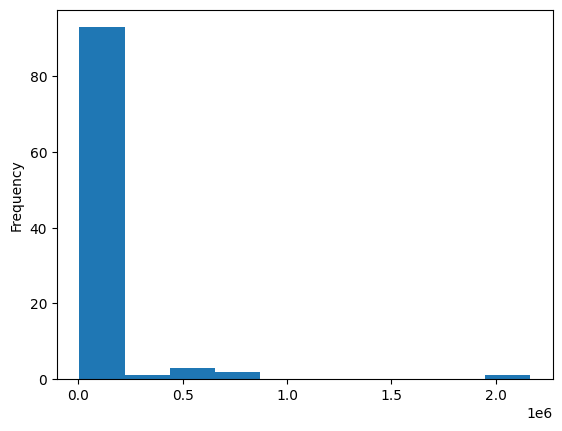

In [26]:
df["area"].plot.hist()

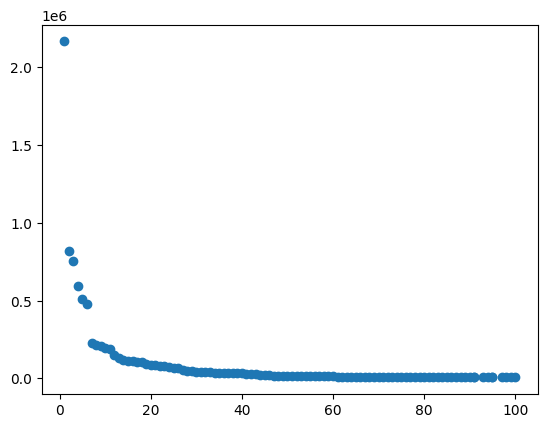

In [27]:
plt.scatter(
    df["rank"],
    df["area"]
)